In [1]:
from __future__ import print_function
from tensorflow import keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
import tensorflow as tf 
# %matplotlib notebook
import matplotlib.pyplot as plt
import numpy as np
import time
def plt_dynamic(x, vy, ty, ax, colors=['b']):
    ax.plot(x, vy, 'b', label="Validation Loss")
    ax.plot(x, ty, 'r', label="Train Loss")
    plt.legend()
    plt.grid()
    fig.canvas.draw()
    plt.show()

In [2]:

batch_size = 128
num_classes = 10
epochs = 25

# input image dimensions
img_rows, img_cols = 28, 28

# the data, split between train and test sets
(x_train, y_train), (x_test, y_test) = mnist.load_data()

if K.image_data_format() == 'channels_first':
    x_train = x_train.reshape(x_train.shape[0], 1, img_rows, img_cols)
    x_test = x_test.reshape(x_test.shape[0], 1, img_rows, img_cols)
    input_shape = (1, img_rows, img_cols)
else:
    x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1)
    x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)
    input_shape = (img_rows, img_cols, 1)


x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255
print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)


11493376/11490434 [==============================] - 0s 0us/step
x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


# The Model:

In [3]:
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3),
                 activation='relu',
                 input_shape=input_shape))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=keras.optimizers.Adadelta(),
              metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 26, 26, 32)        320       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 24, 24, 64)        18496     
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 12, 12, 64)        0         
_________________________________________________________________
dropout (Dropout)            (None, 12, 12, 64)        0         
_________________________________________________________________
flatten (Flatten)            (None, 9216)              0         
_________________________________________________________________
dense (Dense)                (None, 128)               1179776   
_________________________________________________________________
dropout_1 (Dropout)          (None, 128)               0

In [4]:


history = model.fit(x_train, y_train,
          batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(x_test, y_test))
score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Train on 60000 samples, validate on 10000 samples
Epoch 1/25
60000/60000 [==============================] - 8s 136us/sample - loss: 2.2820 - accuracy: 0.1404 - val_loss: 2.2348 - val_accuracy: 0.3266
Epoch 2/25
60000/60000 [==============================] - 3s 56us/sample - loss: 2.2122 - accuracy: 0.2534 - val_loss: 2.1529 - val_accuracy: 0.5203
Epoch 3/25
60000/60000 [==============================] - 3s 54us/sample - loss: 2.1306 - accuracy: 0.3576 - val_loss: 2.0482 - val_accuracy: 0.6113
Epoch 4/25
60000/60000 [==============================] - 3s 54us/sample - loss: 2.0215 - accuracy: 0.4425 - val_loss: 1.9115 - val_accuracy: 0.6780
Epoch 5/25
60000/60000 [==============================] - 3s 55us/sample - loss: 1.8880 - accuracy: 0.5025 - val_loss: 1.7398 - val_accuracy: 0.7246
Epoch 6/25
60000/60000 [==============================] - 3s 56us/sample - loss: 1.7285 - accuracy: 0.5555 - val_loss: 1.5408 - val_accuracy: 0.7684
Epoch 7/25
60000/60000 [==============================]

### Plotting Train and validation Loss :

Test score: 0.39227074842453
Test accuracy: 0.8941


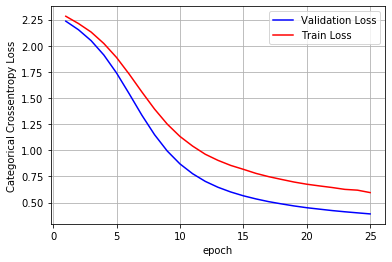

In [5]:
score = model.evaluate(x_test, y_test, verbose=0) 
print('Test score:', score[0]) 
print('Test accuracy:', score[1])

fig,ax = plt.subplots(1,1)
ax.set_xlabel('epoch') ; ax.set_ylabel('Categorical Crossentropy Loss')

# list of epoch numbers
x = list(range(1,epochs+1))

vy = history.history['val_loss']
ty = history.history['loss']
plt_dynamic(x, vy, ty, ax)

- Following image is of the Handwritten digit " 4 " from our train dataset 
- We will observe how this image behaves as we pass it on through different layers of our CNN

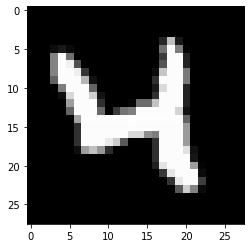

In [6]:
plt.imshow(x_train[20].reshape(28,28), cmap = 'gray');

In [7]:
layer_outputs = [layer.output for layer in model.layers]
activation_model = Model(inputs=model.input, outputs=layer_outputs)

#https://gist.github.com/NISH1001/7287b01aaa531aec08ab21359f7d3342 
def display_activation(activations, col_size, row_size, act_index): 
    activation = activations[act_index]
    activation_index=0
    fig, ax = plt.subplots(row_size, col_size, figsize=(row_size*2.5,col_size*1.5))
    for row in range(0,row_size):
        for col in range(0,col_size):
            ax[row][col].imshow(activation[0, :, :, activation_index], cmap='gray')
            activation_index += 1

# Visualizing Layer : 1

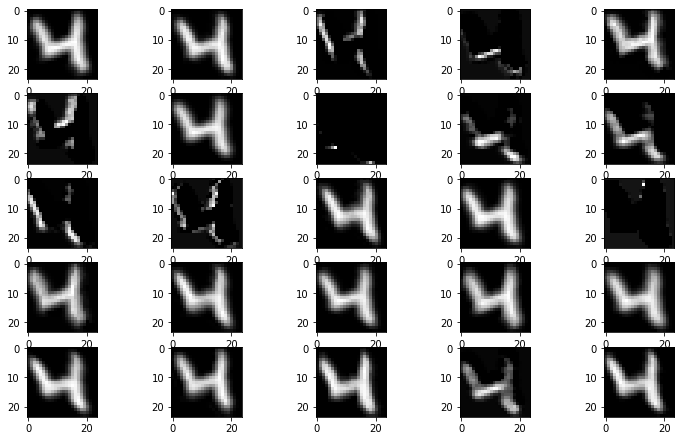

In [8]:
activations = activation_model.predict(x_train[20].reshape(1,28,28,1))
display_activation(activations, 5,5,1)

# Visualizing Layer 2


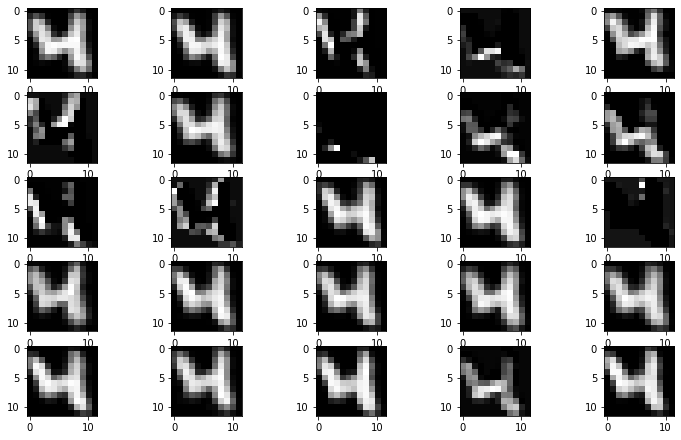

In [9]:
display_activation(activations, 5,5,2)

# Visualizing Layer 3

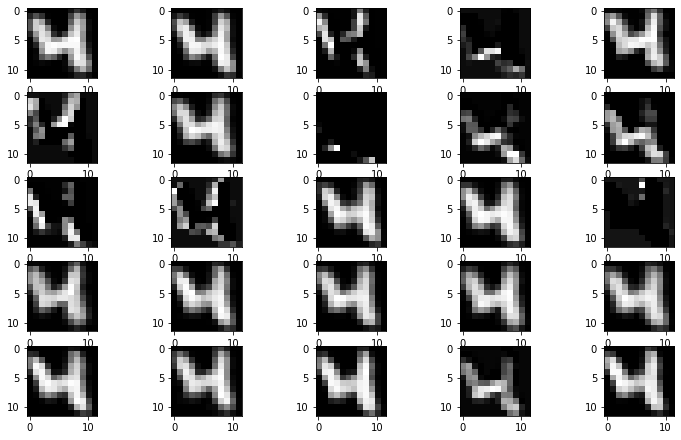

In [10]:
display_activation(activations, 5,5,3)